In [51]:
###############################
### Kalman calibration code ###
###############################

# Import all the 
import serial
import serial.tools.list_ports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import csv
from datetime import datetime
import os
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [52]:
# List available serial ports
def list_serial_ports():
    """List all available serial ports"""
    ports = serial.tools.list_ports.comports()
    available_ports = []
    
    print("Available serial ports [index : name]:")
    for i, port in enumerate(ports):
        print(f"{i}: {port.device} - {port.description}")
        available_ports.append(port.device)
    
    return available_ports

# List available ports
available_ports = list_serial_ports()

Available serial ports [index : name]:
0: COM3 - Intel(R) Active Management Technology - SOL (COM3)
1: COM5 - USB Serial Port (COM5)


In [53]:
# Configuration parameters
PORT_INDEX = 1      # Match port index from above
BAUD_RATE = 9600    # Serial baud
TIMEOUT = 1         # Serial timeout in seconds

# Data collection parameters
DURATION = 10  # Data collection duration [sec]
OUTPUT_FILE = f"data/collected_data_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

# Select port
if available_ports:
    PORT = available_ports[PORT_INDEX]
    print(f"Selected port: {PORT}")
else:
    print("No serial ports found!")
    PORT = None

Selected port: COM5


In [54]:
# Data Collection Function
def collect_serial_data(port, baudrate, duration, output_file):
    """
    Collect data from serial port for specified duration and save to CSV
    """
    data = []
    start_time = time.time()
    
    try:
        # Open serial port
        ser = serial.Serial(port, baudrate, timeout=TIMEOUT)
        print(f"Connected to {port} at {baudrate} baud")
        print(f"Collecting data for {duration} seconds...")
        
        # Clear buffer
        time.sleep(2)
        ser.reset_input_buffer()
        
        # Collect data
        while time.time() - start_time < duration:
            try:
                # Read line from serial
                line = ser.readline().decode('utf-8').strip()
                
                if line:
                    # Parse the data (format: "Accel X = X.XXX , Y = Y.XXX, Z = Z.XXX")
                    # Example: "Accel X = 0.123 , Y = -0.456, Z = 0.789"
                    
                    # Method 1: Simple string parsing
                    if 'Accel X =' in line:
                        parts = line.split(',')
                        x_part = parts[0].split('=')[1].strip()
                        y_part = parts[1].split('=')[1].strip()
                        z_part = parts[2].split('=')[1].strip()
                        
                        try:
                            x_val = float(x_part)
                            y_val = float(y_part)
                            z_val = float(z_part)
                            
                            timestamp = time.time() - start_time  # Relative time
                            data.append({
                                'timestamp': timestamp,
                                'accel_x': x_val,
                                'accel_y': y_val,
                                'accel_z': z_val
                            })
                            
                            # Optional: Print progress
                            if len(data) % 10 == 0:
                                print(f"Collected {len(data)} samples...")
                                
                        except ValueError:
                            # Skip lines with invalid data
                            pass
                            
            except UnicodeDecodeError:
                # Skip lines that can't be decoded
                continue
            except KeyboardInterrupt:
                print("\nData collection interrupted by user")
                break
                
        print(f"\nCollection complete! Total samples: {len(data)}")
        
        # Save to CSV
        if data:
            df = pd.DataFrame(data)
            df.to_csv(output_file, index=False)
            print(f"Data saved to {output_file}")
        else:
            print("No data collected!")
            return None
            
    except serial.SerialException as e:
        print(f"Error opening serial port: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error: {e}")
        return None
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print("Serial port closed")
    
    return data

In [55]:
# Run data collection
if PORT:
    raw_data = collect_serial_data(PORT, BAUD_RATE, DURATION, OUTPUT_FILE)
else:
    print("No valid port selected. Please check your connection.")
    raw_data = None

Connected to COM5 at 9600 baud
Collected 10 samples...
Collected 20 samples...
Collected 30 samples...
Collected 40 samples...
Collected 50 samples...

Collection complete! Total samples: 58
Data saved to data/collected_data_20260301_114413.csv
Serial port closed


In [56]:
# Load and Explore Data

# Load the data if collection was successful
if raw_data:
    df = pd.DataFrame(raw_data)
else:
    # Try to load from existing file if collection failed
    try:
        df = pd.read_csv(OUTPUT_FILE)
        print(f"Loaded data from {OUTPUT_FILE}")
    except:
        print("No data available. Please run data collection first.")
        df = None

if df is not None:
    # Display first few rows
    print("First 5 rows of data:")
    display(df.head())
    
    # Basic information about the dataset
    print("\nDataset info:")
    print(f"Number of samples: {len(df)}")
    print(f"Time span: {df['timestamp'].max():.2f} seconds")
    print(f"Sampling rate: {len(df)/df['timestamp'].max():.1f} Hz")
    
    # Check for missing values
    print(f"\nMissing values:\n{df.isnull().sum()}")


First 5 rows of data:


,timestamp,accel_x,accel_y,accel_z
0,2.066763,-0.980,0.008,0.031
1,2.209895,-0.992,-0.035,0.051
2,2.352909,-1.119,-0.019,-0.073
3,2.495938,-1.040,-0.014,0.044
4,2.638874,-0.917,-0.011,0.064



Dataset info:
Number of samples: 58
Time span: 10.05 seconds
Sampling rate: 5.8 Hz

Missing values:
timestamp    0
accel_x      0
accel_y      0
accel_z      0
dtype: int64


In [57]:
# Statistical Analysis

if df is not None:
    # Calculate statistics for each axis
    stats = pd.DataFrame({
        'Axis': ['X', 'Y', 'Z'],
        'Mean': [df['accel_x'].mean(), df['accel_y'].mean(), df['accel_z'].mean()],
        'Std Dev': [df['accel_x'].std(), df['accel_y'].std(), df['accel_z'].std()],
        'Min': [df['accel_x'].min(), df['accel_y'].min(), df['accel_z'].min()],
        'Max': [df['accel_x'].max(), df['accel_y'].max(), df['accel_z'].max()],
        'RMS': [np.sqrt(np.mean(df['accel_x']**2)), 
                np.sqrt(np.mean(df['accel_y']**2)),
                np.sqrt(np.mean(df['accel_z']**2))]
    })
    
    print("\n=== Statistical Analysis ===")
    display(stats.round(4))
    
    # Calculate magnitude of acceleration vector
    df['magnitude'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
    
    print(f"\nMagnitude statistics:")
    print(f"Mean magnitude: {df['magnitude'].mean():.4f}")
    print(f"Std magnitude: {df['magnitude'].std():.4f}")



=== Statistical Analysis ===


,Axis,Mean,Std Dev,Min,Max,RMS
0,X,-1.0106,0.0777,-1.174,-0.869,1.0135
1,Y,-0.0253,0.0410,-0.140,0.040,0.0478
2,Z,0.0227,0.0516,-0.082,0.141,0.0559



Magnitude statistics:
Mean magnitude: 1.0133
Std magnitude: 0.0777


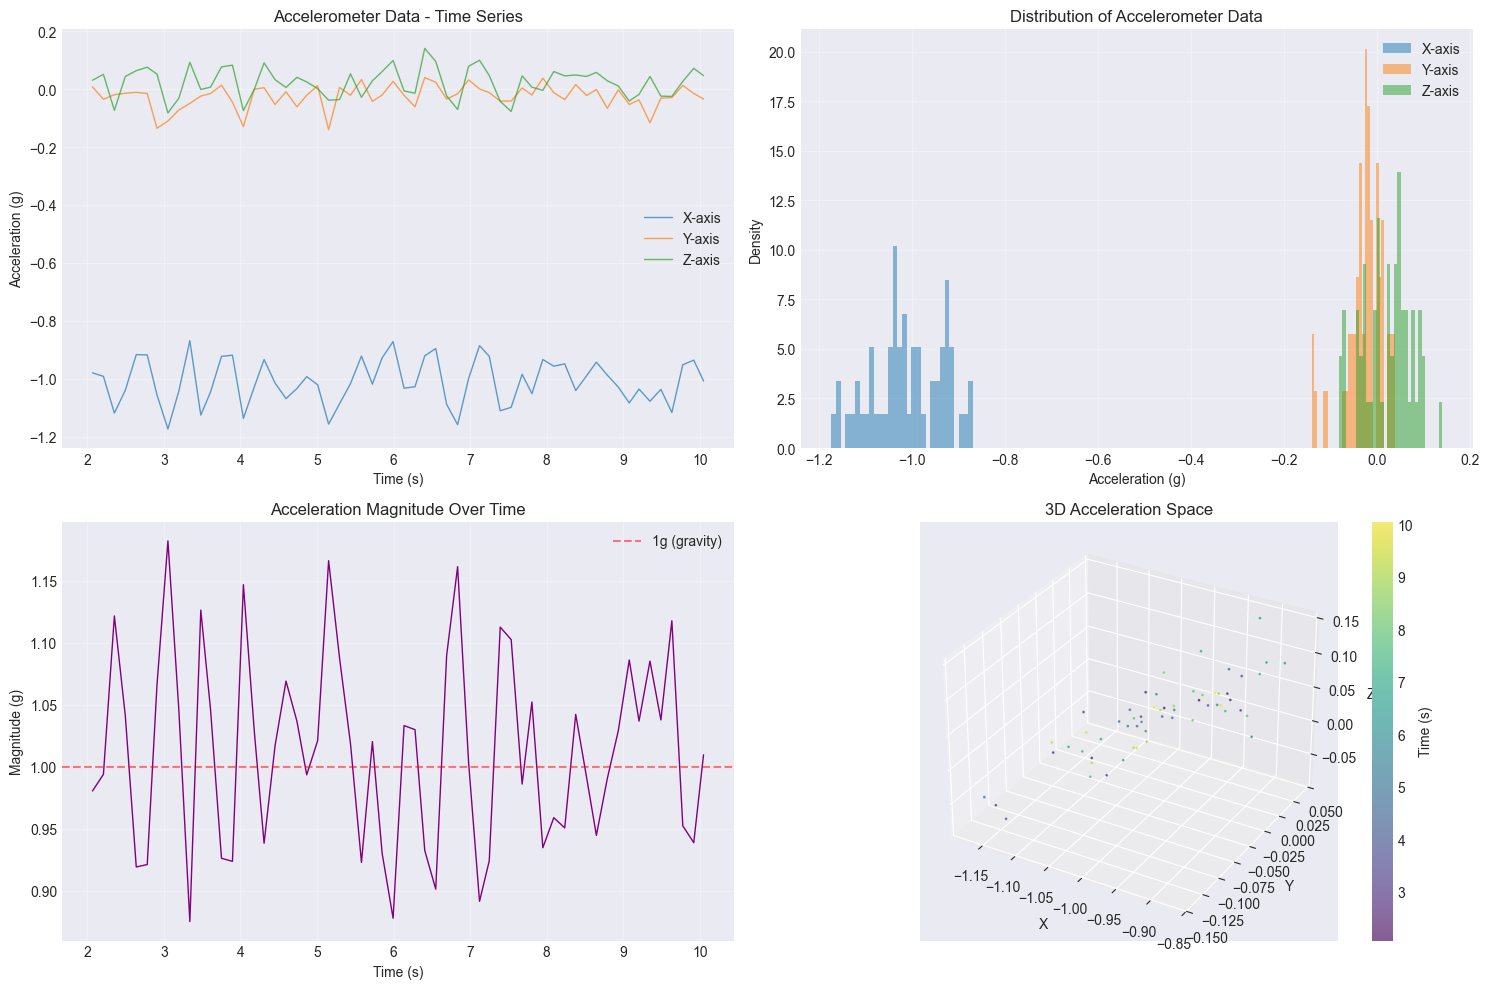

In [58]:
# Data Visualization

if df is not None:
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(15, 10))
    
    # Plot 1: Time series of all axes
    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(df['timestamp'], df['accel_x'], label='X-axis', linewidth=1, alpha=0.7)
    ax1.plot(df['timestamp'], df['accel_y'], label='Y-axis', linewidth=1, alpha=0.7)
    ax1.plot(df['timestamp'], df['accel_z'], label='Z-axis', linewidth=1, alpha=0.7)
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Acceleration (g)')
    ax1.set_title('Accelerometer Data - Time Series')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Histograms of each axis
    ax2 = plt.subplot(2, 2, 2)
    ax2.hist(df['accel_x'], bins=30, alpha=0.5, label='X-axis', density=True)
    ax2.hist(df['accel_y'], bins=30, alpha=0.5, label='Y-axis', density=True)
    ax2.hist(df['accel_z'], bins=30, alpha=0.5, label='Z-axis', density=True)
    ax2.set_xlabel('Acceleration (g)')
    ax2.set_ylabel('Density')
    ax2.set_title('Distribution of Accelerometer Data')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Magnitude over time
    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(df['timestamp'], df['magnitude'], color='purple', linewidth=1)
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Magnitude (g)')
    ax3.set_title('Acceleration Magnitude Over Time')
    ax3.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='1g (gravity)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: 3D scatter plot (optional - can be slow for large datasets)
    ax4 = plt.subplot(2, 2, 4, projection='3d')
    
    # Downsample for 3D plot if dataset is large
    if len(df) > 1000:
        plot_df = df.iloc[::len(df)//1000]
    else:
        plot_df = df
        
    scatter = ax4.scatter(plot_df['accel_x'], plot_df['accel_y'], plot_df['accel_z'], 
                         c=plot_df['timestamp'], cmap='viridis', s=1, alpha=0.6)
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')
    ax4.set_title('3D Acceleration Space')
    plt.colorbar(scatter, ax=ax4, label='Time (s)')
    
    plt.tight_layout()
    plt.show()


In [59]:
# Interactive Data Visualization with Plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import os
from IPython.display import HTML, display

if df is not None:
    # Create a subplot figure with 2x2 grid
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Accelerometer Data - Time Series', 
                       'Distribution of Accelerometer Data',
                       'Acceleration Magnitude Over Time',
                       '3D Acceleration Space'),
        specs=[[{'secondary_y': False}, {'type': 'xy'}],
               [{'type': 'xy'}, {'type': 'scatter3d'}]]
    )
    
    # Plot 1: Time series of all axes
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_x'], 
                  mode='lines', name='X-axis', line=dict(width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_y'], 
                  mode='lines', name='Y-axis', line=dict(width=1)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['accel_z'], 
                  mode='lines', name='Z-axis', line=dict(width=1)),
        row=1, col=1
    )
    
    # Plot 2: Histograms of each axis
    fig.add_trace(
        go.Histogram(x=df['accel_x'], name='X-axis', opacity=0.5, 
                    histnorm='probability density', nbinsx=30),
        row=1, col=2
    )
    fig.add_trace(
        go.Histogram(x=df['accel_y'], name='Y-axis', opacity=0.5,
                    histnorm='probability density', nbinsx=30),
        row=1, col=2
    )
    fig.add_trace(
        go.Histogram(x=df['accel_z'], name='Z-axis', opacity=0.5,
                    histnorm='probability density', nbinsx=30),
        row=1, col=2
    )
    
    # Plot 3: Magnitude over time
    fig.add_trace(
        go.Scatter(x=df['timestamp'], y=df['magnitude'], 
                  mode='lines', name='Magnitude', line=dict(color='purple', width=1)),
        row=2, col=1
    )
    
    # Add horizontal line for 1g (gravity)
    fig.add_hline(y=1.0, line_dash="dash", line_color="red", 
                  annotation_text="1g (gravity)", row=2, col=1)
    
    # Plot 4: 3D scatter plot
    if len(df) > 1000:
        plot_df = df.iloc[::len(df)//1000].copy()
    else:
        plot_df = df.copy()
    
    fig.add_trace(
        go.Scatter3d(
            x=plot_df['accel_x'], 
            y=plot_df['accel_y'], 
            z=plot_df['accel_z'],
            mode='markers',
            marker=dict(
                size=2,
                color=plot_df['timestamp'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title="Time (s)")
            ),
            name='3D Scatter'
        ),
        row=2, col=2
    )
    
    # Update layout
    fig.update_layout(
        height=900,
        showlegend=True,
        title_text="Accelerometer Data Analysis - Interactive Plot",
        hovermode='x unified'
    )
    
    # Update axes labels
    fig.update_xaxes(title_text="Time (s)", row=1, col=1)
    fig.update_yaxes(title_text="Acceleration (g)", row=1, col=1)
    
    fig.update_xaxes(title_text="Acceleration (g)", row=1, col=2)
    fig.update_yaxes(title_text="Density", row=1, col=2)
    
    fig.update_xaxes(title_text="Time (s)", row=2, col=1)
    fig.update_yaxes(title_text="Magnitude (g)", row=2, col=1)
    
    # Save to HTML file
    html_file = "html/accelerometer_plot.html"
    fig.write_html(html_file)
    print(f"Plot saved as '{html_file}'")
    
    # # Display the HTML file in the notebook
    # print("\nDisplaying plot in notebook:")
    # print("-" * 50)
    
    # # Method 1: Using IFrame (usually works)
    # from IPython.display import IFrame
    # display(IFrame(html_file, width=1000, height=900))
    
    # Method 2: Alternative - read and display HTML directly
    print("\nAlternative: Click the link below to open in browser:")
    display(HTML(f'<a href="{html_file}" target="_blank">Open {html_file} in new tab</a>'))
    
    # # Show file path
    # full_path = os.path.abspath(html_file)
    # print(f"\nFile location: {full_path}")


Plot saved as 'html/accelerometer_plot.html'

Alternative: Click the link below to open in browser:


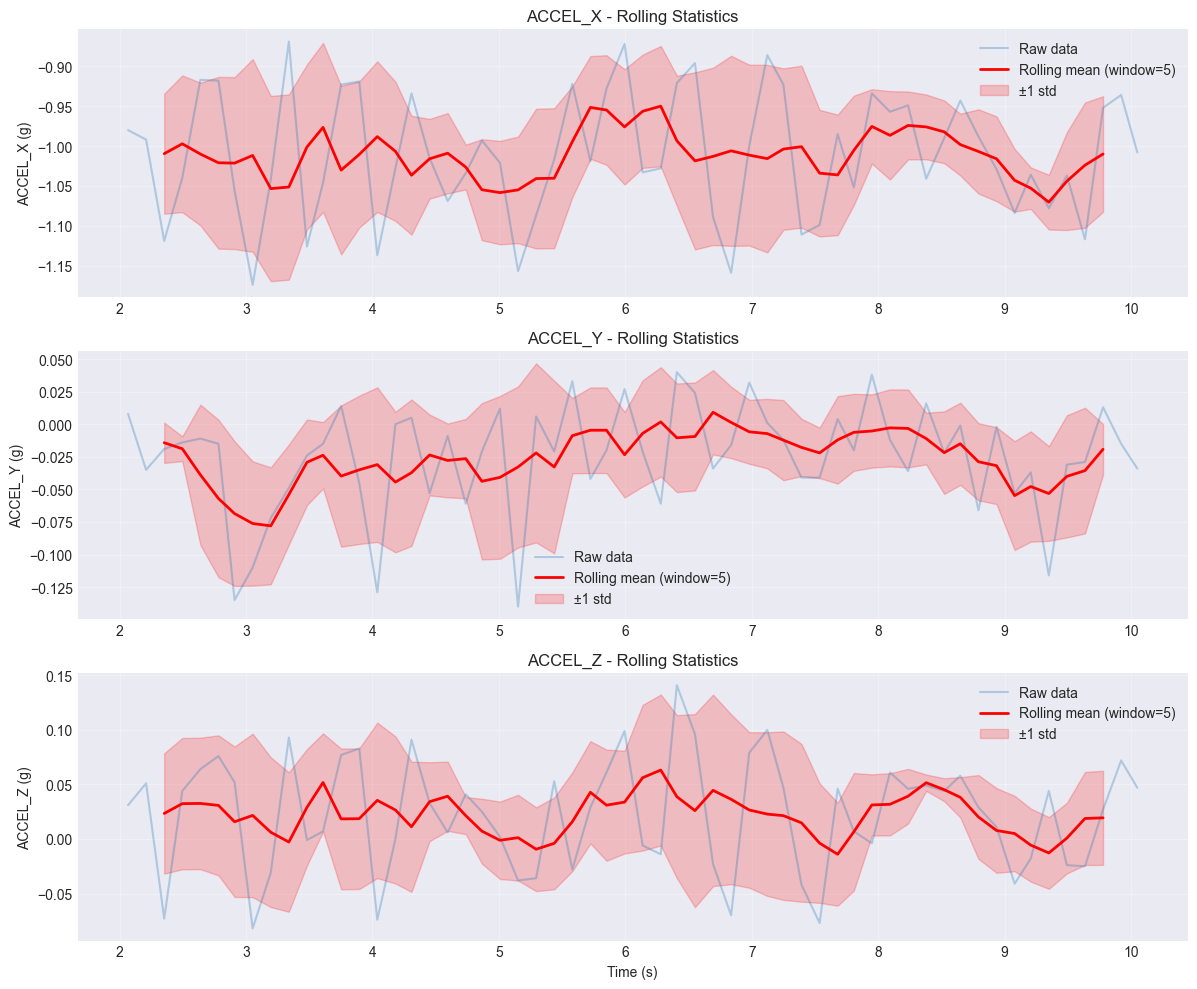

In [60]:
# Advanced Analysis - Rolling Statistics

if df is not None:
    # Calculate rolling statistics
    window_size = min(50, len(df)//10)  # Adaptive window size
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    for i, axis in enumerate(['accel_x', 'accel_y', 'accel_z']):
        # Calculate rolling mean and std
        rolling_mean = df[axis].rolling(window=window_size, center=True).mean()
        rolling_std = df[axis].rolling(window=window_size, center=True).std()
        
        # Plot
        axes[i].plot(df['timestamp'], df[axis], alpha=0.3, label='Raw data')
        axes[i].plot(df['timestamp'], rolling_mean, 'r-', linewidth=2, label=f'Rolling mean (window={window_size})')
        axes[i].fill_between(df['timestamp'], 
                            rolling_mean - rolling_std, 
                            rolling_mean + rolling_std, 
                            alpha=0.2, color='r', label='±1 std')
        axes[i].set_ylabel(f'{axis.upper()} (g)')
        axes[i].set_title(f'{axis.upper()} - Rolling Statistics')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    axes[2].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()

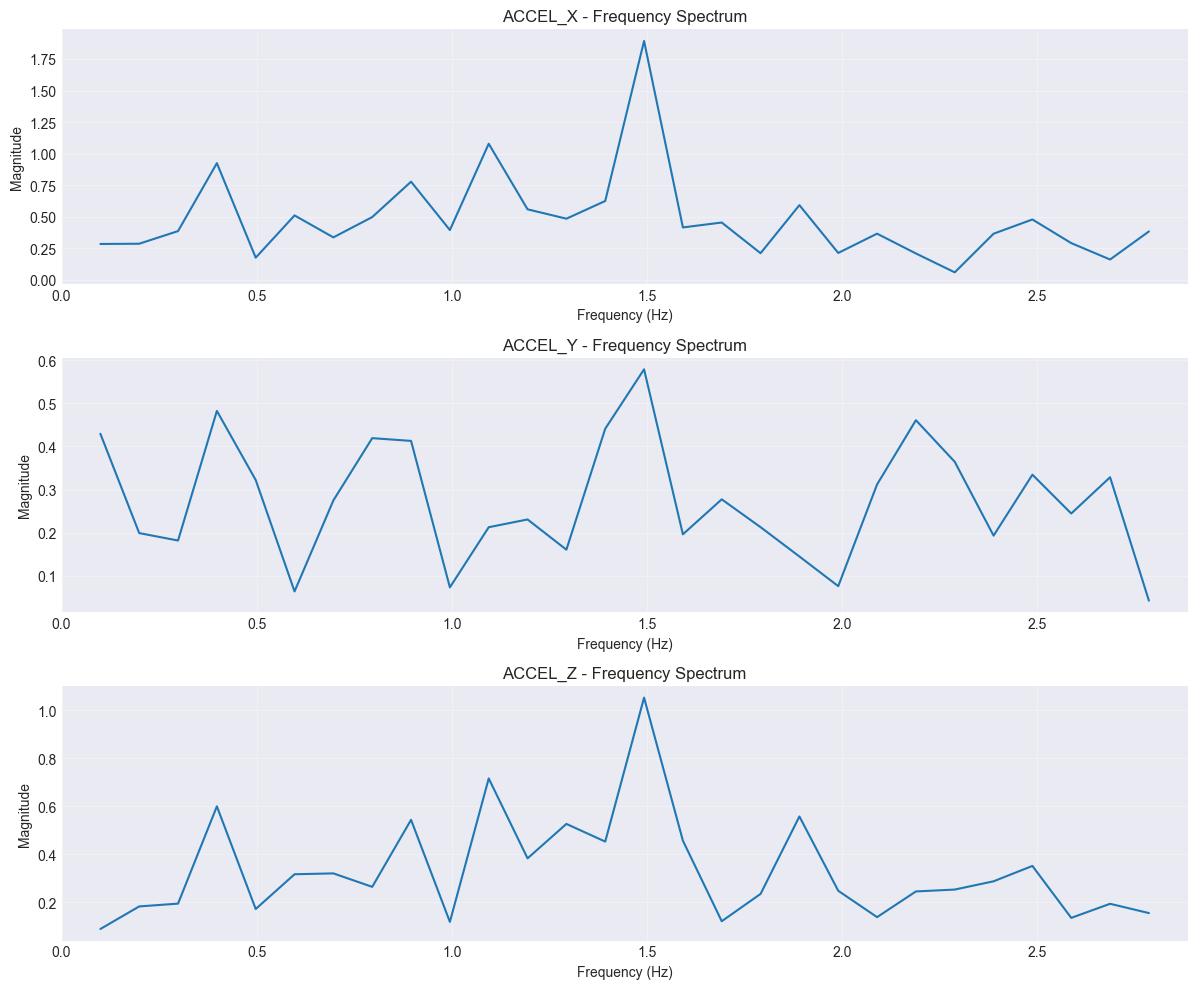

Estimated sampling rate: 5.8 Hz
Nyquist frequency: 2.9 Hz


In [61]:
# FFT Analysis (Frequency Domain)

if df is not None and len(df) > 10:
    from scipy import signal
    
    # Calculate FFT for each axis
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    sampling_rate = len(df) / df['timestamp'].max()
    
    for i, axis in enumerate(['accel_x', 'accel_y', 'accel_z']):
        # Detrend the data
        data_detrended = signal.detrend(df[axis].values)
        
        # Compute FFT
        fft_vals = np.fft.fft(data_detrended)
        fft_freq = np.fft.fftfreq(len(data_detrended), 1/sampling_rate)
        
        # Take positive frequencies only
        pos_mask = fft_freq > 0
        fft_freq = fft_freq[pos_mask]
        fft_mag = np.abs(fft_vals[pos_mask])
        
        # Plot
        axes[i].plot(fft_freq, fft_mag)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Magnitude')
        axes[i].set_title(f'{axis.upper()} - Frequency Spectrum')
        axes[i].set_xlim([0, sampling_rate/2])  # Nyquist frequency
        axes[i].grid(True, alpha=0.3)
        
        # Optional: log scale for better visualization
        #axes[i].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Estimated sampling rate: {sampling_rate:.1f} Hz")
    print(f"Nyquist frequency: {sampling_rate/2:.1f} Hz")


In [62]:
# Export Results

if df is not None:
    # Create summary report
    summary_stats = pd.DataFrame({
        'Axis': ['X', 'Y', 'Z'],
        'Mean': [df['accel_x'].mean(), df['accel_y'].mean(), df['accel_z'].mean()],
        'Std': [df['accel_x'].std(), df['accel_y'].std(), df['accel_z'].std()],
        'Min': [df['accel_x'].min(), df['accel_y'].min(), df['accel_z'].min()],
        'Max': [df['accel_x'].max(), df['accel_y'].max(), df['accel_z'].max()]
    })
    
    # Save summary to CSV
    OUTPUT_FILE_SUM = f"summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    summary_file = f"summary/{OUTPUT_FILE_SUM}"
    summary_stats.to_csv(summary_file, index=False)
    print(f"Summary statistics saved to {summary_file}")
    
    # Display final summary
    print("\n=== FINAL SUMMARY ===")
    print(f"Data file: {OUTPUT_FILE}")
    print(f"Total samples: {len(df)}")
    print(f"Recording duration: {df['timestamp'].max():.2f} seconds")
    print(f"Average sampling rate: {len(df)/df['timestamp'].max():.1f} Hz")
    print("\nAxis Statistics:")
    display(summary_stats.round(4))




Summary statistics saved to summary/summary_20260301_114424.csv

=== FINAL SUMMARY ===
Data file: data/collected_data_20260301_114413.csv
Total samples: 58
Recording duration: 10.05 seconds
Average sampling rate: 5.8 Hz

Axis Statistics:


,Axis,Mean,Std,Min,Max
0,X,-1.0106,0.0777,-1.174,-0.869
1,Y,-0.0253,0.0410,-0.140,0.040
2,Z,0.0227,0.0516,-0.082,0.141


In [63]:
# Clean Up

# Close any remaining plots
plt.close('all')
print("Analysis complete!")

Analysis complete!
